# Data Analysis and Processing Notebook

Project : Decolonizing Health Professions Education Research: An Analysis of Global Network Patterns and Equity Implications

Author : P. Sitthirat et al.

This notebook serves as a comprehensive guide for processing and analyzing the network of co-authorship in health professions education community. It includes data cleaning, manipulation, and analysis.

Objectives:
- Processing the bibliometric database.
- Geocoding for the author.
- Conducting social network analysis.

Requirements: Ensure the following libraries are installed before running the notebook: `pip install -r scripts/requirements.txt`

### 1. Initial Setup and Library Imports

This cell initializes the notebook with necessary configurations and imports key libraries and custom modules for data processing, geocoding, and network analysis.

### Features:
1. **IPython Extensions**:
   - `%load_ext autoreload`: Automatically reloads modules before executing cells, ensuring the latest code changes are applied.
   - `%autoreload 2`: Reloads all imported modules every time a cell is executed.

2. **General Library Imports**:
   - `os`: For interacting with the operating system.
   - `pandas`: For data manipulation and analysis.
   - `numpy`: For numerical operations.
   - `tqdm`: For progress bars in loops.
   - `geopandas`: For geographical data manipulation and analysis.
   - `matplotlib.pyplot`: For main visualization.

3. **Advanced Library Imports**:
   - `itertools.zip_longest`: Allows iteration over multiple lists of unequal length, filling missing values with a specified placeholder so no data is lost.
   - `fuzzywuzzy`: Fuzzy string matching, which compares two text strings and returns a similarity score (0–100).
   - `inset_axes`: For zooming some region in the big map.
   - `upsetplot`: For building the upset plot.
   - `networkx`: For social network analysis (base libraries, please use with `scripts/network.py`).
   - `community`: Louvain community detection (python-louvain), used for modularity and participation-coefficient analysis.

3. **Custom Modules** from `scripts` folder:
   - `geocoder`: For geocoding the affiliation dataset, including the batch `geocode_affiliations` pipeline.
   - `network`: For building co-authorship graphs and calculating network parameters.
   - `visualization`: For the choropleth, bump chart, and network-on-map plotting functions reused throughout Section 3.
   - `process.DataManipulation`: For parsing author/affiliation strings and imputing missing geocoding results.

4. **Notebook Settings**:
   - `clear_output`: For clearing the output before further operations
   - `pd.set_option('future.no_silent_downcasting', True)`: Ensures that pandas raises warnings for downcasting operations.
   - `warnings.simplefilter('ignore', DeprecationWarning)`: Suppresses deprecation warnings for a cleaner output.

### Code:
This configuration ensures an efficient and clean working environment for data analysis and processing.

In [1]:
%load_ext autoreload
%autoreload 2

# General libraries
import os
import pandas as pd
import numpy as np
from pathlib import Path
# from tqdm import tqdm
import geopandas as gpd
import matplotlib.pyplot as plt

# # Advanced libraries
# from itertools import zip_longest
# from fuzzywuzzy import fuzz
# from fuzzywuzzy import process
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from upsetplot import UpSet, from_indicators
import networkx as nx
import community as community_louvain

# # Custom modules
from scripts import scrp_article
from scripts import network
from scripts import visualization
# from scripts.process import DataManipulation

from IPython.display import clear_output
# pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)

#### Global Map and Official Language Imports

Due to we have to analyze and visualize the data into the global map, `world` would be imported to be the base map for further analysis
Reference map was downloaded from [Natural Earth Data](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-0-countries/) which is 10-metre resolution of country border.

Morover, official language of each countries was extracted from [Resource Watch](https://resourcewatch.org/data/explore/soc_071_world_languages?section=Discover&selectedCollection=&zoom=3&lat=0&lng=0&pitch=0&bearing=0&basemap=dark&labels=light&layers=%255B%257B%2522dataset%2522%253A%252220662342-dcdd-4a42-9f58-bcc80217de71%2522%252C%2522opacity%2522%253A1%252C%2522layer%2522%253A%2522f2d76e6b-060d-4dc9-83ea-284bef6b2aae%2522%257D%255D&aoi=&page=1&sort=most-viewed&sortDirection=-1).

These two files would be first imported using `geopandas`.

In [2]:
world = gpd.read_file('data/world-map/ne_10m_admin_0_countries.zip')
world = world[world['ADMIN'] != 'Antarctica']

language = gpd.read_file('data/world-map/world_languages.zip')

world = world.merge(language[['COUNTRY', 'FIRST_OFFI']], how='inner', left_on='GEOUNIT', right_on='COUNTRY')

#### Setting the Visualization

For consistent visulization all visual parameters such as font, size, color would be set here.

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Arial"],
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

### 2. Data Retrieval and Management

This section imports the bibliometric database from [OpenAlex API](https://openalex.org/) which are the scholar outputs from five journals between Jan 2015 to June 2026 period.

In [4]:
journal = pd.read_csv('data/source_id.csv')
group = 'econ' # changeable
start_date = "2015-01-01"
end_date = "2026-06-30"

works_scraped = pd.DataFrame()
authorships_scraped = pd.DataFrame()

for id in journal[journal['group'] == group]['id']:

    works = scrp_article.retrieve_journal_works(
        source_id=id,
        start_date=start_date,
        end_date=end_date,
    )

    w_df, a_df = scrp_article.flatten_works(works)

    works_scraped = pd.concat([works_scraped, w_df], ignore_index=True)
    authorships_scraped = pd.concat([authorships_scraped, a_df], ignore_index=True)

    clear_output()

scraped_path = Path(f"output/scraped/{group}")
scraped_path.mkdir(parents=True, exist_ok=True)
works_scraped.to_csv(scraped_path / 'works_scraped.csv', index=True)
authorships_scraped.to_csv(scraped_path / 'authorships_scraped.csv', index=True)

print(f"Retrieval successful from {len(journal[journal['group'] == group]['id'])} journals from {start_date} to {end_date} including {len(works_scraped)} initial works. Scraped files were saved in 'output/scraped/{group}' folder.")

Retrieval successful from 20 journals from 2015-01-01 to 2026-06-30 including 18760 initial works. Scraped files were saved in 'output/scraped/econ' folder.


In [5]:
works_df = pd.read_csv(scraped_path / 'works_scraped.csv')

# Include only some type of articles
included_work_types = ['article', 'review', 'book-chapter', 'editorial', 'conference-abstract']
works_df = works_df[works_df['work_type'].isin(included_work_types)].copy()

# Export valid work dataframe
metadata_path = Path(f"data/metadata/{group}")
metadata_path.mkdir(parents=True, exist_ok=True)
works_df.to_csv(metadata_path / 'works.csv', index=False)

In [ ]:
from scripts import geocode_workflow

authorships_df = pd.read_csv(scraped_path / 'authorships_scraped.csv')

# Include only author of valid works and drop duplicated rows
authorships_df = authorships_df[authorships_df['work_id'].isin(works_df['work_id'])].copy()
authorships_df = authorships_df.drop_duplicates(subset=['work_id', 'author_id']).reset_index(drop=True)

# Fills institution_country_code from the shared crosswalks in output/map/
# (institution_id -> affiliation -> author_id) plus same-author/same-work
# inference. See scripts/geocode_workflow.py.
authorships_df = geocode_workflow.impute_country_codes(authorships_df)

# If rows are still missing a country code afterwards, export the
# not-yet-labeled institutions/affiliations for this field, fill in the
# institution_country_code column (e.g. by asking Claude to label them, same
# as this session), then merge the labels back into the shared crosswalk:
#
#   geocode_workflow.export_pending(authorships_df, 'institution', group)
#   geocode_workflow.export_pending(authorships_df, 'affiliation', group)
#   # ...label output/map/pending/geocode_{institution,affiliation}_{group}.csv...
#   geocode_workflow.merge_labels('institution', f'output/map/pending/geocode_institution_{group}.csv')
#   geocode_workflow.merge_labels('affiliation', f'output/map/pending/geocode_affiliation_{group}.csv')
#
# ...then re-run this cell to pick up the newly-labeled rows.

In [8]:
authorships_df.to_csv(metadata_path / 'authorships.csv', index=False)

### 3. Country-level Analysis

We analysed the distribution and network pattern using the retrievel metadata dataframe from `data/metadata` folder. The analysis included:
- display distribution of scholar output in each country and income level
- social network analysis

In [9]:
# Import cleaned publication and country group datset
works_df = pd.read_csv(metadata_path / 'works.csv')
authorships_df = pd.read_csv(metadata_path / 'authorships.csv')

income_gr = pd.read_csv('data/world-map/country_group.csv')
income_gr = income_gr.merge(world[['ADM0_A3', 'FIRST_OFFI', 'ISO_A2_EH']], how='left', left_on='Code', right_on='ADM0_A3')

df_foranalyse = authorships_df.merge(income_gr[['ISO_A2_EH', 'Income group', 'Region']], how='left', left_on='institution_country_code', right_on='ISO_A2_EH')
df_foranalyse = df_foranalyse.merge(world[['ISO_A2_EH', 'FIRST_OFFI']], how='left', on='ISO_A2_EH')

display(df_foranalyse)

,Unnamed: 0,work_id,doi,title,publication_year,author_id,author_name,orcid,author_position,is_corresponding,raw_affiliation,institution_id,institution_name,institution_country_code,institution_type,institution_ror,ISO_A2_EH,Income group,Region,FIRST_OFFI
0,0,https://openalex.org/W3126081245,https://doi.org/10.1093/qje/qjw024,Measuring Economic Policy Uncertainty*,2016,https://openalex.org/A5019884843,Scott Baker,https://orcid.org/0000-0001-5085-3106,first,False,Finance,NaN,NaN,US,NaN,NaN,US,High income,North America,English
1,1,https://openalex.org/W3126081245,https://doi.org/10.1093/qje/qjw024,Measuring Economic Policy Uncertainty*,2016,https://openalex.org/A5044421873,Nicholas Bloom,https://orcid.org/0000-0002-1600-7819,middle,False,NaN,NaN,NaN,US,NaN,NaN,US,High income,North America,English
2,2,https://openalex.org/W3126081245,https://doi.org/10.1093/qje/qjw024,Measuring Economic Policy Uncertainty*,2016,https://openalex.org/A5102869039,Steven J. Davis,https://orcid.org/0000-0002-5901-7021,last,False,NaN,NaN,NaN,US,NaN,NaN,US,High income,North America,English
3,3,https://openalex.org/W2942870997,https://doi.org/10.1093/qje/qjz014,The Effect of Minimum Wages on Low-Wage Jobs*,2019,https://openalex.org/A5069364966,Doruk Cengiz,NaN,first,False,"University of Massachusetts, Amherst",https://openalex.org/I24603500,University of Massachusetts Amherst,US,education,https://ror.org/0072zz521,US,High income,North America,English
4,4,https://openalex.org/W2942870997,https://doi.org/10.1093/qje/qjz014,The Effect of Minimum Wages on Low-Wage Jobs*,2019,https://openalex.org/A5109516884,Arindrajit Dubé,NaN,middle,False,"University of Massachusetts, Amherst, National...",https://openalex.org/I1321305853,National Bureau of Economic Research,US,nonprofit,https://ror.org/04grmx538,US,High income,North America,English
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56754,52464,https://openalex.org/W7160926548,https://doi.org/10.1287/mksc.2023.0487,An Empirical Analysis of Optimal Nonlinear Pri...,2026,https://openalex.org/A5084690883,Russ Yoon,NaN,last,False,"Institute for Data, Systems, and Society, Mass...",https://openalex.org/I63966007,Massachusetts Institute of Technology,US,education,https://ror.org/042nb2s44,US,High income,North America,English
56755,52465,https://openalex.org/W7165030803,https://doi.org/10.1287/mksc.2024.1138,On the Value of Coalition Loyalty Programs,2026,https://openalex.org/A5030429492,Yan Liu,https://orcid.org/0000-0002-6370-0683,first,False,"Department of Logistics and Maritime Studies, ...",https://openalex.org/I14243506,Hong Kong Polytechnic University,HK,education,https://ror.org/0030zas98,HK,High income,East Asia & Pacific,Cantonese
56756,52466,https://openalex.org/W7165030803,https://doi.org/10.1287/mksc.2024.1138,On the Value of Coalition Loyalty Programs,2026,https://openalex.org/A5013936008,Jingmai Wang,NaN,middle,True,"Department of Supply Chain Management, College...",https://openalex.org/I180726961,Shenzhen University,CN,education,https://ror.org/01vy4gh70,CN,Upper middle income,East Asia & Pacific,Standard Chinese or Mandarin
56757,52468,https://openalex.org/W7165030803,https://doi.org/10.1287/mksc.2024.1138,On the Value of Coalition Loyalty Programs,2026,https://openalex.org/A5100661963,Yulan Wang,https://orcid.org/0000-0003-4184-590X,middle,False,"Department of Logistics and Maritime Studies, ...",https://openalex.org/I14243506,Hong Kong Polytechnic University,HK,education,https://ror.org/0030zas98,HK,High income,East Asia & Pacific,Cantonese


#### Publication trends by income group and country

Income group,High income,Low income,Lower middle income,Upper middle income
publication_year,,,,
2015,1119,23,33,83
2016,2077,654,676,699
2017,1298,21,35,83
2018,1292,13,31,71
2019,1186,10,30,80
2020,1380,21,43,106
2021,1476,9,28,113
2022,1252,6,26,81
2023,1268,6,25,99


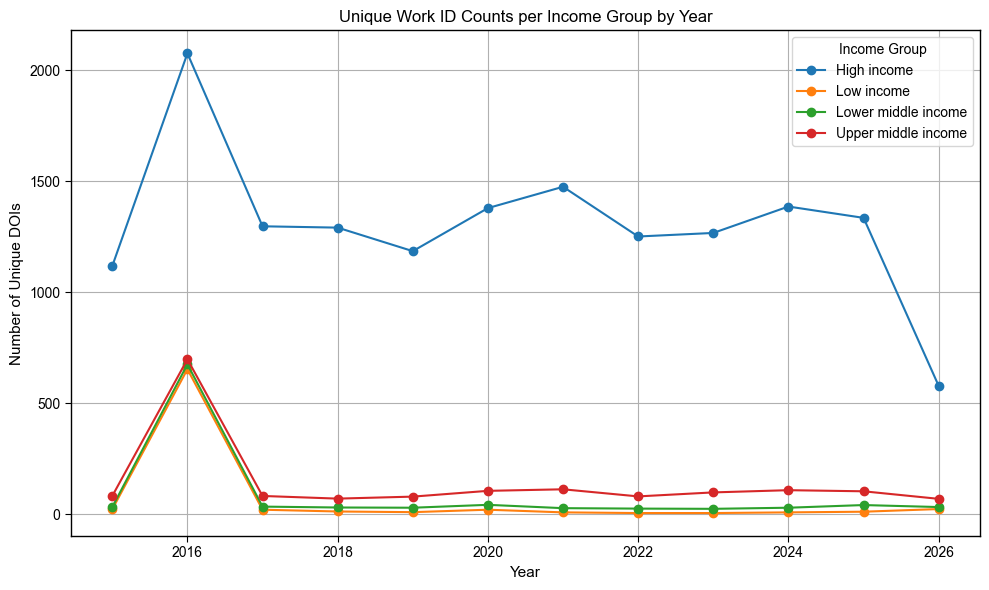

In [10]:
# Count publications per income group
counts_income = df_foranalyse.groupby(['publication_year', 'Income group'])['work_id'].nunique().reset_index()
counts_income_pivot = counts_income.pivot(index='publication_year', columns='Income group', values='work_id').fillna(0)
display(counts_income_pivot)

plt.figure(figsize=(10, 6))

for col in counts_income_pivot.columns:
    plt.plot(counts_income_pivot.index, counts_income_pivot[col], marker='o', label=col)

plt.title("Unique Work ID Counts per Income Group by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique DOIs")
plt.legend(title="Income Group")
plt.grid(True)
plt.tight_layout()
plt.show()

Income group,High income,Low income,Lower middle income,Upper middle income
publication_year,,,,
2015,2183,34,44,97
2016,3552,820,841,876
2017,2565,38,54,115
2018,2682,23,41,93
2019,2475,21,43,104
2020,2897,31,56,145
2021,3180,18,39,148
2022,2765,7,32,115
2023,2911,7,27,147


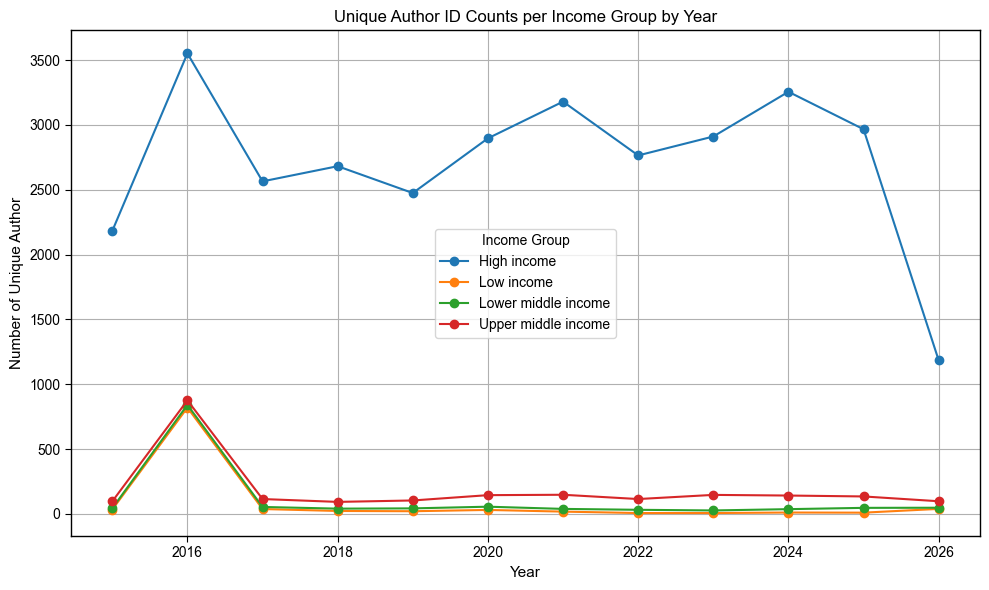

In [11]:
# Count authors per income group
counts_author = df_foranalyse.groupby(['publication_year', 'Income group'])['author_id'].nunique().reset_index()
counts_author_pivot = counts_author.pivot(index='publication_year', columns='Income group', values='author_id').fillna(0)
display(counts_author_pivot)

plt.figure(figsize=(10, 6))

for col in counts_author_pivot.columns:
    plt.plot(counts_author_pivot.index, counts_author_pivot[col], marker='o', label=col)

plt.title("Unique Author ID Counts per Income Group by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Author")
plt.legend(title="Income Group")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Global and regional publication distribution

/Users/p.sitthirat/Desktop/HPSR_QUANTI/MedEdSNA/scripts/visualization.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


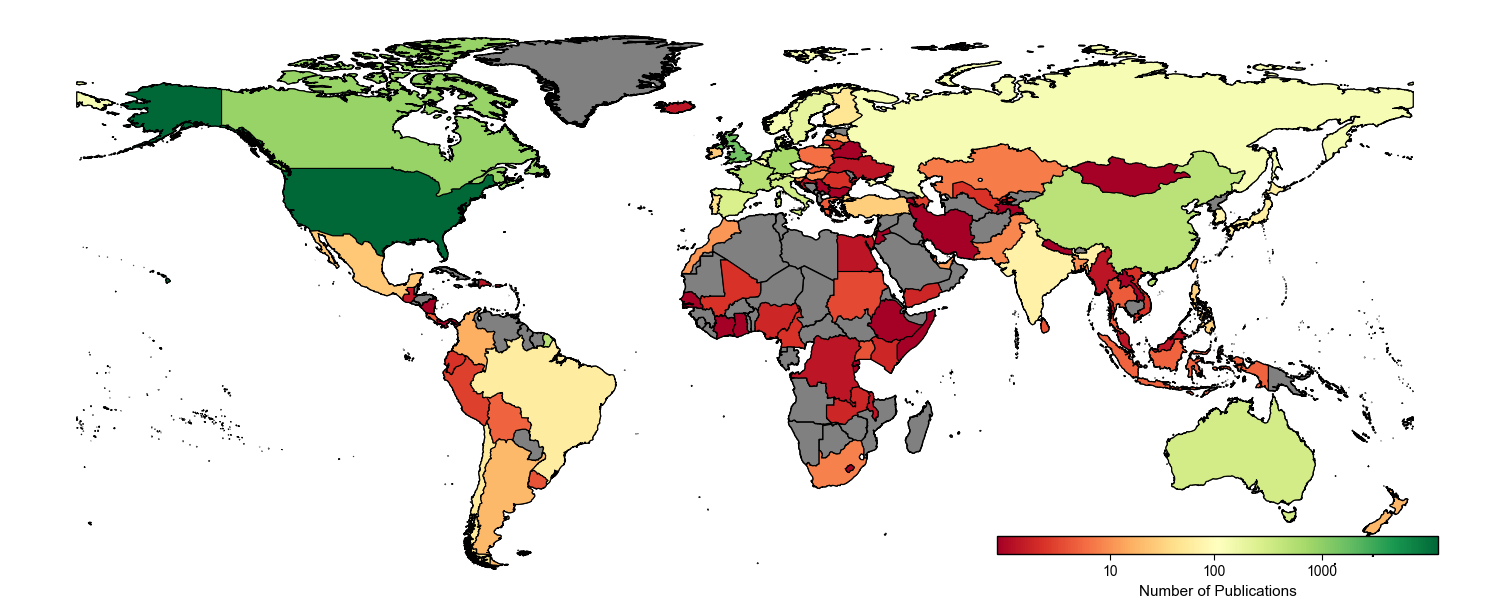

In [12]:
# Count publications per country
counts_country = df_foranalyse.groupby(['Income group', 'institution_country_code'])['work_id'].nunique().reset_index()
counts_country.columns = ['Income group', 'ISO_A2_EH', 'Publication Count']

# Merge author data with map data
world_plt = world[world['ADMIN'] != 'Antarctica']  # Exclude Antarctica
merged = world_plt.merge(counts_country, on='ISO_A2_EH', how='left')
merged['Publication Count'] = merged['Publication Count'].fillna(0)
merged['Log Publication Count'] = np.log1p(merged['Publication Count'])

# Separate subsets for plotting
has_published = merged[merged['Publication Count'] > 0]
no_published = merged[merged['Publication Count'] == 0]

visualization.plot_choropleth(world_plt, has_published, no_published)

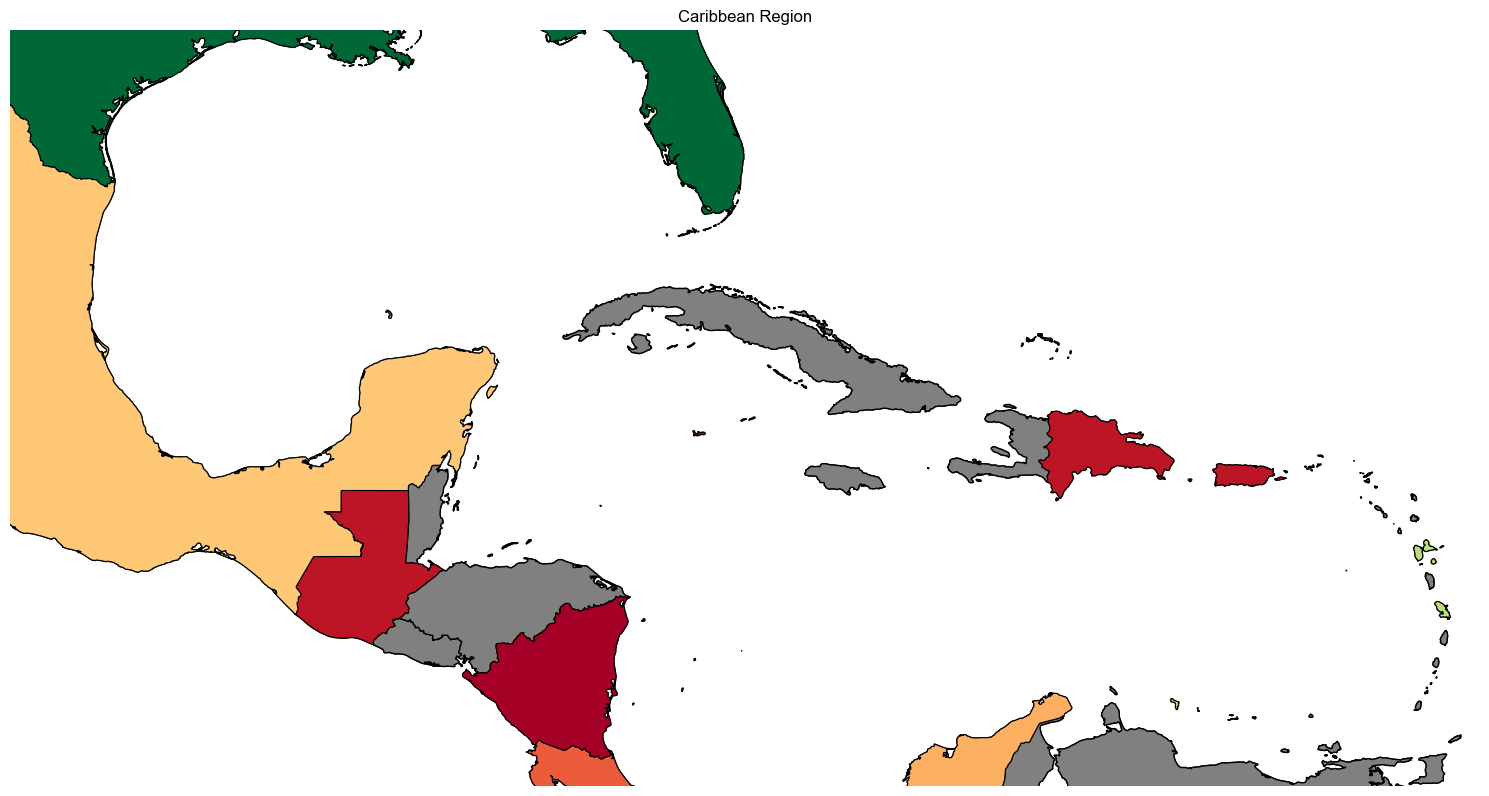

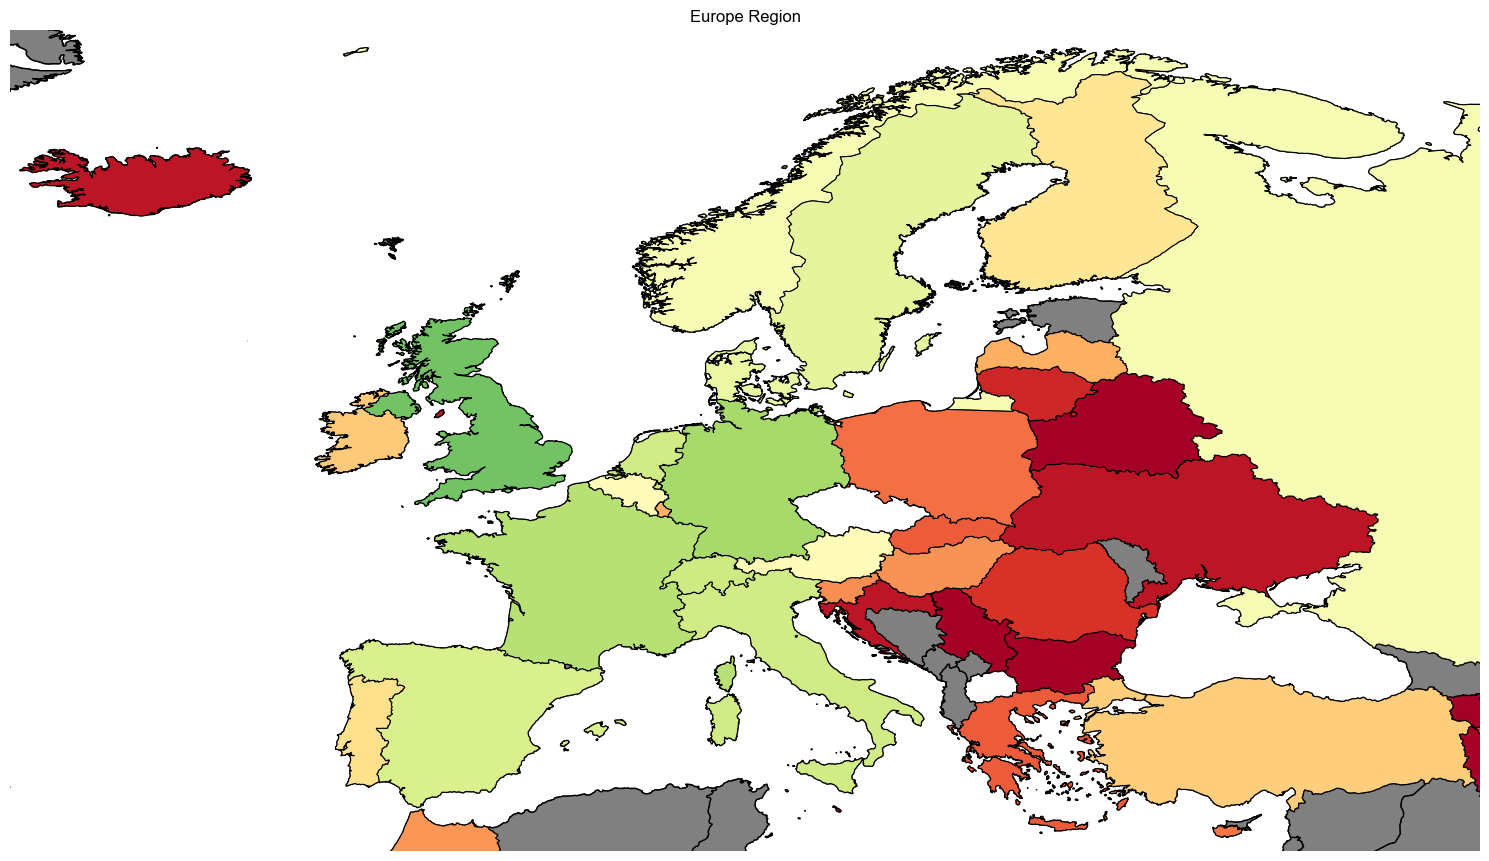

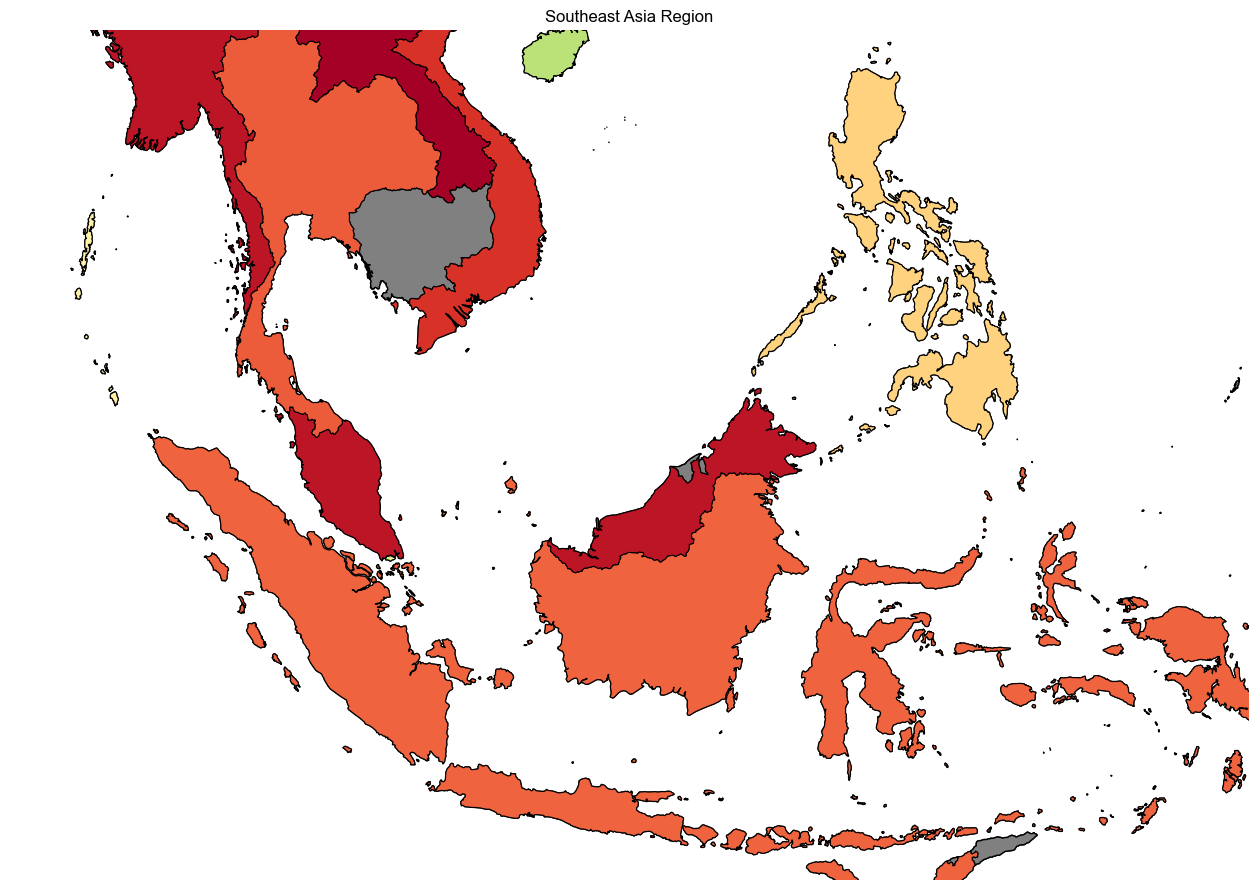

In [13]:
# Plot some region
visualization.plot_choropleth(world_plt, has_published, no_published, xlim=(-100, -60), ylim=(10, 30), title="Caribbean Region")
visualization.plot_choropleth(world_plt, has_published, no_published, xlim=(-25, 45), ylim=(34, 72), title="Europe Region")
visualization.plot_choropleth(world_plt, has_published, no_published, xlim=(90, 135), ylim=(-10, 20), title="Southeast Asia Region")

#### Collaboration patterns across income groups

In [14]:
# Pivot the collaboration patterns
df_pivot = df_foranalyse.groupby(by=['work_id', 'publication_year']).agg({
    'institution_country_code': set,
    'Region': set,
    'Income group': set
}).reset_index()

df_pivot['no_Country'] = df_pivot['institution_country_code'].apply(lambda x: len(x))
df_pivot['no_Income'] = df_pivot['Income group'].apply(lambda x: len(x))

df_pivot['count_grp'] = df_pivot.apply(
    lambda row: (
        'High only' if (row['no_Income'] == 1 and 'High income' in str(row['Income group'])) else
        'Developing only' if ('High income' not in str(row['Income group'])) else
        'Mixed'
    ),
    axis=1
)

pivot_counts = df_pivot.pivot_table(
    index='publication_year',
    columns='count_grp',
    aggfunc='size',
    fill_value=0
).reset_index()

display(pivot_counts)

count_grp,publication_year,Developing only,High only,Mixed
0,2015,17,1034,85
1,2016,13,1357,720
2,2017,10,1204,94
3,2018,13,1209,83
4,2019,10,1088,98
5,2020,12,1256,124
6,2021,14,1353,123
7,2022,11,1154,98
8,2023,10,1154,114
9,2024,12,1258,129


#### Multi-income-group collaboration (UpSet plot)

In [10]:
# Create upset plot
df_pivot = df_foranalyse.groupby(by=['work_id', 'publication_year']).agg({
    'institution_country_code': set,
    'Region': set,
    'Income group': set
}).reset_index()
df_pivot['no_Country'] = df_pivot['institution_country_code'].apply(lambda x: len(x))
subset = df_pivot[df_pivot['no_Country'] > 1]['work_id'].drop_duplicates()
subset = pd.DataFrame(subset, columns=['work_id'])

high_income = df_foranalyse[df_foranalyse['Income group'] == 'High income']['work_id'].copy()
upper_middle_income = df_foranalyse[df_foranalyse['Income group'] == 'Upper middle income']['work_id'].copy()
lower_middle_income = df_foranalyse[df_foranalyse['Income group'] == 'Lower middle income']['work_id'].copy()
low_income = df_foranalyse[df_foranalyse['Income group'] == 'Low income']['work_id'].copy()

# Add membership flags
subset['High income'] = subset['work_id'].isin(high_income)
subset['Upper middle income'] = subset['work_id'].isin(upper_middle_income)
subset['Lower middle income'] = subset['work_id'].isin(lower_middle_income)
subset['Low income'] = subset['work_id'].isin(low_income)

upset_data = from_indicators(['High income', 'Upper middle income', 'Lower middle income', 'Low income'], subset)
display(upset_data)
# Plot
# UpSet(upset_data, subset_size='count', show_counts=True).plot()
# plt.show()

work_id  \
High income Upper middle income Lower middle income Low income                                     
True        False               False               False       https://openalex.org/W1012864297   
                                                    False       https://openalex.org/W1125901883   
                                                    False       https://openalex.org/W1152847323   
                                                    False       https://openalex.org/W1438322574   
                                                    False       https://openalex.org/W1476359573   
...                                                                                          ...   
            True                True                False       https://openalex.org/W7166518604   
            False               False               False       https://openalex.org/W7166570915   
                                True                False       https://openalex.org/W7166580690   
                                False               False        https://openalex.org/W864597737   
                                                    False        https://openalex.org/W942372543   

                                                                High income  \
High income Upper middle income Lower middle income Low income                
True        False               False               False              True   
                                                    False              True   
                                                    False              True   
                                                    False              True   
                                                    False              True   
...                                                                     ...   
            True                True                False              True   
            False               False               False              True   
                                True                False              True   
                                False               False              True   
                                                    False              True   

                                                                Upper middle income  \
High income Upper middle income Lower middle income Low income                        
True        False               False               False                     False   
                                                    False                     False   
                                                    False                     False   
                                                    False                     False   
                                                    False                     False   
...                                                                             ...   
            True                True                False                      True   
            False               False               False                     False   
                                True                False                     False   
                                False               False                     False   
                                                    False                     False   

                                                                Lower middle income  \
High income Upper middle income Lower middle income Low income                        
True        False               False               False                     False   
                                                    False                     False   
                                                    False                     False   
                                                    False                     False   
                                                    False                     False   
...                

#### Global co-authorship network construction (2015–2024)

Build a yearly co-authorship graph per country and accumulate it into a single running network `G_all`, tracking centrality and network statistics (via `scripts/network.py`) as each year is added.

In [15]:
# Social Network Analysis
results = pd.DataFrame()
G_all = nx.Graph()

for year in range(2015, 2026):
    # Filter only the data for the current year
    df_year = df_foranalyse[df_foranalyse['publication_year'] == year]

    # Use the existing function to construct the graph for this year
    G_year = network.network_coauthorship(df_year, 'institution_country_code', id_col='work_id', node_label=['Region', 'Income group', 'FIRST_OFFI'])

    # Merge G_year into G_all
    for u, v, data in G_year.edges(data=True):
        if G_all.has_edge(u, v):
            G_all[u][v]['weight'] += data['weight']
        else:
            G_all.add_edge(u, v, weight=data['weight'])

    for node, data in G_year.nodes(data=True):
        if node not in G_all:
            G_all.add_node(node)
        for attr, value in data.items():
            G_all.nodes[node][attr] = value

    result = network.network_params(df_year, G_all, homophily_attr=['Region', 'Income group', 'FIRST_OFFI'])
    result['publication_year'] = year
    results = pd.concat([results, result], ignore_index=True)

    # Degree centrality
    deg_cent = nx.degree_centrality(G_all)
    top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

    print("Top 10 Degree Centrality:")
    for node, val in top_deg:
        print(f"{node}: {val:.4f}")

    # Betweenness centrality
    bet_cent = nx.betweenness_centrality(G_all, normalized=True)
    top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\nTop 10 Betweenness Centrality:")
    for node, val in top_bet:
        print(f"{node}: {val:.4f}")

    print(f'Year {year} network analysed.')

G_country = G_all
display(results)

Building coauthorship graph: 100%|██████████| 1136/1136 [00:00<00:00, 23669.21it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.9038
GB: 0.4615
FR: 0.3077
CA: 0.2885
DE: 0.2692
ES: 0.2115
CN: 0.1923
IT: 0.1923
SG: 0.1923
CH: 0.1923

Top 10 Betweenness Centrality:
US: 0.7106
GB: 0.1281
ES: 0.0402
DE: 0.0381
FR: 0.0347
CH: 0.0214
CA: 0.0204
AR: 0.0120
IT: 0.0088
CN: 0.0066
Year 2015 network analysed.


Building coauthorship graph: 100%|██████████| 2090/2090 [00:00<00:00, 24848.76it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.9344
GB: 0.5410
CA: 0.4262
DE: 0.3443
FR: 0.3443
IT: 0.3115
CN: 0.2951
ES: 0.2459
CH: 0.2459
SE: 0.2295

Top 10 Betweenness Centrality:
US: 0.6244
GB: 0.1048
FR: 0.0478
CA: 0.0449
DE: 0.0374
ES: 0.0239
CH: 0.0216
IT: 0.0170
CN: 0.0133
AR: 0.0086
Year 2016 network analysed.


Building coauthorship graph: 100%|██████████| 1308/1308 [00:00<00:00, 26373.18it/s]

...

Building coauthorship graph: 100%|██████████| 1399/1399 [00:00<00:00, 25613.43it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.9596
GB: 0.5859
FR: 0.5253
CA: 0.5051
DE: 0.5051
IT: 0.4343
AU: 0.4242
ES: 0.4141
NL: 0.3737
SE: 0.3737

Top 10 Betweenness Centrality:
US: 0.5239
GB: 0.0676
CA: 0.0480
FR: 0.0429
DE: 0.0428
AU: 0.0293
IT: 0.0181
NL: 0.0156
SG: 0.0129
SE: 0.0128
Year 2024 network analysed.


Building coauthorship graph: 100%|██████████| 1352/1352 [00:00<00:00, 22109.63it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.9528
GB: 0.5660
FR: 0.5189
DE: 0.4906
CA: 0.4811
IT: 0.4245
AU: 0.4057
ES: 0.3962
BE: 0.3679
NL: 0.3585

Top 10 Betweenness Centrality:
US: 0.5449
GB: 0.0607
FR: 0.0475
CA: 0.0422
CN: 0.0300
DE: 0.0284
AU: 0.0253
DK: 0.0220
IT: 0.0163
NL: 0.0153
Year 2025 network analysed.


,None,No of Publications,Single Author,Single Country,Nodes,Edges,Density,Average Clustering,Average Degree,Max Degree,Top Degree Centrality,Top Betweenness Centrality,Top Closeness Centrality,Top Eigenvector Centrality,Average Participation Coefficient,Top Participation Coefficient,No. of Communities,Modularity Score,Largest connected node,Average Shortest Path Length,Graph Diameter,Small-World Coefficient,Homophily on Region,Homophily on Income group,Homophily on FIRST_OFFI,publication_year
0,None,1136,221,763,53,148,0.107402,0.511355,5.584906,47,0.903846,0.710620,0.912281,0.444425,0.219779,0.555846,4,0.063189,53,2.005806,3,5.131148,0.344595,0.709459,0.094595,2015
1,None,2090,765,992,62,232,0.122686,0.594919,7.483871,57,0.934426,0.624438,0.938462,0.372551,0.155293,0.480516,3,0.033156,62,1.952935,3,5.784768,0.362069,0.681034,0.073276,2016
2,None,1308,283,832,74,299,0.110700,0.595214,8.081081,67,0.917808,0.615299,0.924051,0.354504,0.135037,0.500000,4,0.029234,74,1.977046,4,6.000731,0.357860,0.632107,0.080268,2017
3,None,1305,227,780,80,363,0.114873,0.632266,9.075000,74,0.936709,0.603818,0.940476,0.332589,0.135278,0.571429,5,0.029067,80,1.951582,3,5.937946,0.341598,0.630854,0.068871,2018
4,None,1196,208,718,84,407,0.116753,0.651988,9.690476,78,0.939759,0.589746,0.943182,0.313383,0.130468,0.500000,5,0.033093,84,1.944923,3,6.514824,0.326781,0.611794,0.068796,2019
5,None,1392,260,809,88,455,0.118861,0.657985,10.340909,82,0.942529,0.570634,0.945652,0.303396,0.118100,0.500000,4,0.035885,88,1.942006,3,6.517227,0.325275,0.602198,0.072527,2020
6,None,1490,238,872,91,518,0.126496,0.690376,11.384615,86,0.955556,0.567143,0.957447,0.285270,0.134322,0.500000,5,0.041336,91,1.918193,3,6.011967,0.322394,0.592664,0.073359,2021
7,None,1263,211,745,92,553,0.132107,0.725920,12.021739,87,0.956044,0.537205,0.957895,0.277282,0.124411,0.500000,4,0.039233,92,1.910416,3,5.911831,0.320072,0.582278,0.070524,2022
8,None,1278,220,738,94,590,0.134981,0.724705,12.553191,89,0.956989,0.535819,0.958763,0.270321,0.128088,0.500000,4,0.038570,94,1.902311,3,5.624860,0.310169,0.576271,0.066102,2023
9,None,1399,223,786,100,686,0.138586,0.749068,13.720000,95,0.959596,0.523862,0.961165,0.255982,0.173423,0.640000,4,0.039002,100,1.893535,3,5.642575,0.336735,0.590379,0.064140,2024


#### Network snapshots and centrality distributions

Build the two temporal network snapshots (2015–2019 and cumulative through 2024) used by the bump charts below, and inspect the distribution of centrality/participation scores across the full network.

In [17]:
# Define color map for income categories
income_colors = {
    'High income': '#1b9e77',
    'Upper middle income': '#d95f02',
    'Lower middle income': '#7570b3',
    'Low income': '#e7298a',
    'Other': '#ffffff'
}

# Keep top N countries per year for the bump charts below
top_n = 15

G_2020 = network.network_coauthorship(df_foranalyse, 'institution_country_code', id_col='work_id', filter_col='publication_year', filter_value=range(2015, 2020))
G_2024 = network.network_coauthorship(df_foranalyse, 'institution_country_code', id_col='work_id')

Building coauthorship graph: 100%|██████████| 22405/22405 [00:01<00:00, 22166.60it/s]


Building coauthorship graph: 100%|██████████| 22405/22405 [00:01<00:00, 22278.46it/s]


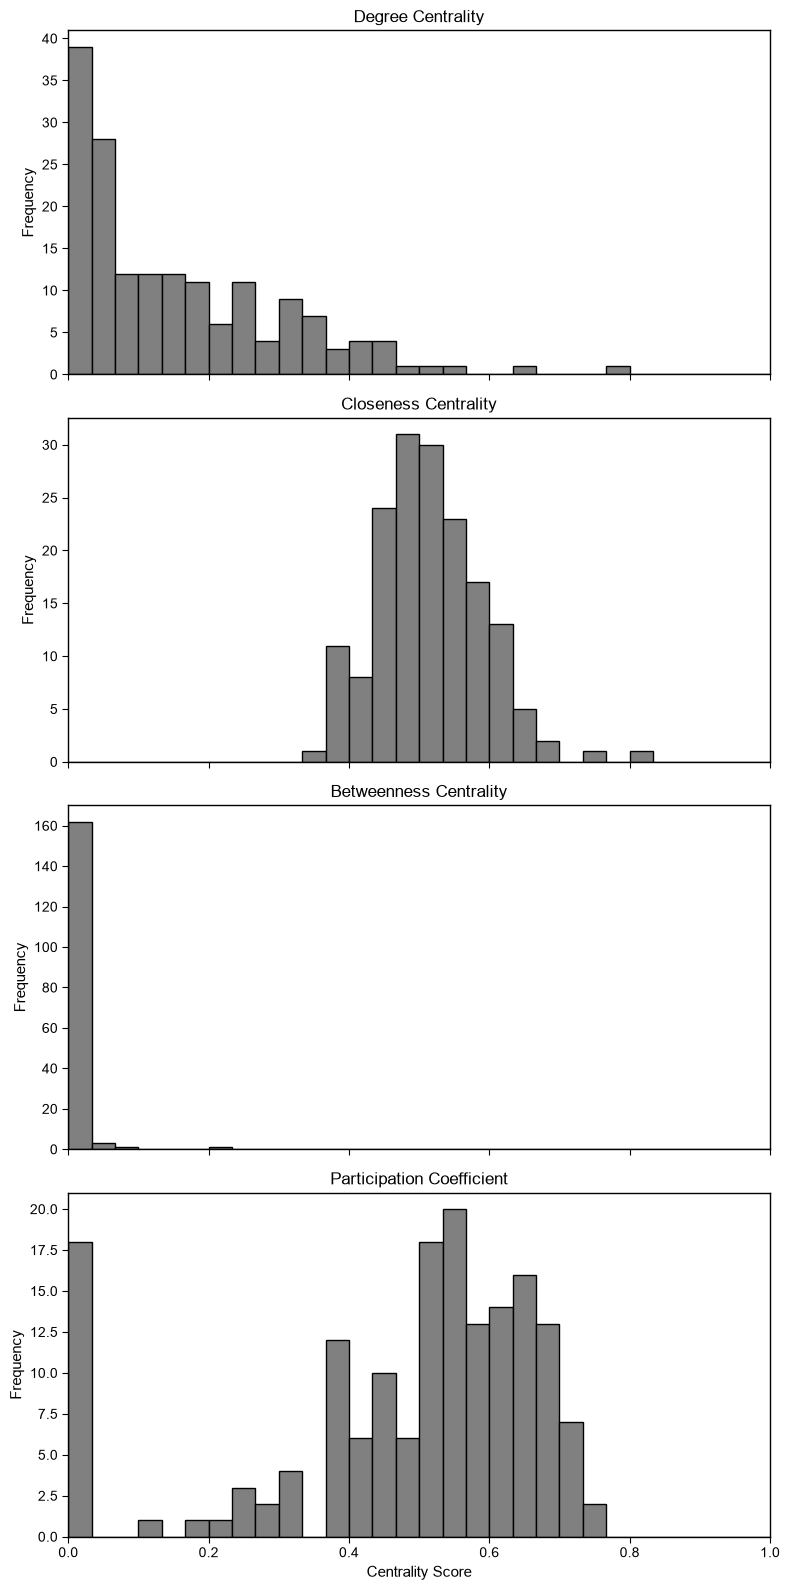

In [19]:
G = network.network_coauthorship(df_foranalyse, 'institution_country_code', id_col='work_id')

deg = nx.degree_centrality(G)
cls = nx.closeness_centrality(G)
btw = nx.betweenness_centrality(G)

partition = community_louvain.best_partition(G, random_state=42)
pc = network.participation_coefficient(G, partition)

# Convert to lists
deg_values = list(deg.values())
cls_values = list(cls.values())
btw_values = list(btw.values())
part_values = list(pc.values())

# Plotting
fig, axs = plt.subplots(4, 1, figsize=(8, 16), sharex=False)
bins = np.linspace(0, 1, 31)  # 30 equal-width bins between 0 and 1

# Degree centrality
axs[0].hist(deg_values, bins=bins, color='grey', edgecolor='black')
axs[0].set_title('Degree Centrality', fontsize=12)
axs[0].set_ylabel('Frequency')
axs[0].set_xlim(0,1)
axs[0].tick_params(labelbottom=False)  # Hide x-axis labels

# Closeness centrality
axs[1].hist(cls_values, bins=bins, color='grey', edgecolor='black')
axs[1].set_title('Closeness Centrality', fontsize=12)
axs[1].set_ylabel('Frequency')
axs[1].set_xlim(0,1)
axs[1].tick_params(labelbottom=False)  # Hide x-axis labels

# Betweenness centrality
axs[2].hist(btw_values, bins=bins, color='grey', edgecolor='black')
axs[2].set_title('Betweenness Centrality', fontsize=12)
axs[2].set_ylabel('Frequency')
axs[2].set_xlim(0,1)
axs[2].tick_params(labelbottom=False)  # Hide x-axis labels

# Participation coefficient
axs[3].hist(part_values, bins=bins, color='grey', edgecolor='black')
axs[3].set_title('Participation Coefficient', fontsize=12)
axs[3].set_ylabel('Frequency')
axs[3].set_xlabel('Centrality Score')
axs[3].set_xlim(0,1)

# Tight layout
plt.tight_layout()
plt.show()

#### Bump charts: centrality rank shifts, 2015 vs 2024

For each centrality measure, rank the top countries in the 2015–2019 snapshot (`G_2020`) and the cumulative 2024 snapshot (`G_2024`), and plot how their rank shifted using `visualization.plot_bump_chart`.

In [ ]:
# Degree centrality
deg_2015 = nx.degree_centrality(G_2020)
deg_2024 = nx.degree_centrality(G_2024)
visualization.plot_bump_chart(deg_2015, deg_2024, income_gr, income_colors, top_n=10)

In [ ]:
# Closeness centrality
cls_2015 = nx.closeness_centrality(G_2020)
cls_2024 = nx.closeness_centrality(G_2024)
visualization.plot_bump_chart(cls_2015, cls_2024, income_gr, income_colors, top_n=top_n)

In [ ]:
# Betweenness centrality
btw_2015 = nx.betweenness_centrality(G_2020)
btw_2024 = nx.betweenness_centrality(G_2024)
visualization.plot_bump_chart(btw_2015, btw_2024, income_gr, income_colors, top_n=top_n)

In [ ]:
# Participation coefficient
partition_2015 = community_louvain.best_partition(G_2020, random_state=42)
partition_2024 = community_louvain.best_partition(G_2024, random_state=42)

pc_2015 = network.participation_coefficient(G_2020, partition_2015)
pc_2024 = network.participation_coefficient(G_2024, partition_2024)

visualization.plot_bump_chart(pc_2015, pc_2024, income_gr, income_colors, top_n=top_n)

#### Co-authorship network on the world map

Overlay the co-authorship network on the world map (via `visualization.plot_network_on_map`), first for all publications, then restricted to publications with a low-income first author.

In [ ]:
df = df_foranalyse.copy()

G_lic = network.network_coauthorship(df, 'institution_country_code', id_col='work_id')
country_income = df[['institution_country_code', 'Income group']].drop_duplicates().set_index('institution_country_code')['Income group'].to_dict()
for node in G_lic.nodes:
    G_lic.nodes[node]['Income group'] = country_income.get(node, 'Other')  # default to 'Other' if missing

visualization.plot_network_on_map(
    G_lic, world, income_colors, edge_scale=0.05,
    title='Co-authorship Network on World Map\nNode Color = Income Group, Labels = LICs Only'
)

In [ ]:
df = df_foranalyse.copy()
lic_set = set(df[(df['Income group'] == 'Low income') & (df['author_position'] == 'first')]['work_id'])
df_lic = df[df['work_id'].isin(lic_set)]

G_lic = network.network_coauthorship(df_lic, 'institution_country_code', id_col='work_id')
country_income = df_lic[['institution_country_code', 'Income group']].drop_duplicates().set_index('institution_country_code')['Income group'].to_dict()
for node in G_lic.nodes:
    G_lic.nodes[node]['Income group'] = country_income.get(node, 'Other')  # default to 'Other' if missing

visualization.plot_network_on_map(
    G_lic, world, income_colors, edge_scale=0.5, node_scale=10,
    title='Co-authorship Network on World Map\nNode Color = Income Group, Labels = LICs Only'
)